In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
data = pd.read_csv(r"C:\Users\sebas\Desktop\Nueva carpeta\uber_fares.csv")
data

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:44:41,2.53,2012-10-28 10:44:41 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:13:35,6.55,2014-03-14 01:13:35 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:41:54,31.56,2009-06-29 00:41:54 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:53:55,15.35,2015-05-20 14:53:55 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [5]:
print(data.shape)
print(data.info())
print(data.head())
print(data.isna().sum())
print("Duplicados:", data.duplicated().sum())

(200000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB
None
        key                 date  fare_amount          pickup_datetime  \
0  24238194  2015-05-07 19:50:00         8.47  2015-05-07 19:50:00 UTC   
1  27835199  2009-07-17 20:00:04         7.60  2009-07-17 20:00:04 UTC   
2  44984355  2009-08-24 21:49:07        12.65  2009-08-24 21:49:

# Primera impresion  
El dataframe consiste de 200k entradas y 9 columnas, de los cuales se tienen lo datos completos de todos salvo las dropout lat y long de 1 viaje.  
 "3   pickup_datetime    200000 non-null  str" <- fechas en string  
No se encuentran duplicados tampoco.  

In [7]:
data.describe(include='all')

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000,200000.000000,200000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
unique,NaN,199877,NaN,199877,NaN,NaN,NaN,NaN,NaN
top,NaN,2015-03-14 22:13:43,NaN,2015-03-14 22:13:43 UTC,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,NaN,2,NaN,NaN,NaN,NaN,NaN
mean,2.771250e+07,NaN,11.362915,NaN,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,NaN,9.943248,NaN,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,NaN,1.000000,NaN,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,NaN,5.970000,NaN,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,NaN,8.430000,NaN,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,NaN,12.660000,NaN,-73.967154,40.767158,-73.963658,40.768001,2.000000


In [9]:
#se convierte data a datetime para poder trabajar mejor con esa informaciónÇ
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'], errors='coerce')
data['pickup_datetime']

0        2015-05-07 19:50:00+00:00
1        2009-07-17 20:00:04+00:00
2        2009-08-24 21:49:07+00:00
3        2009-06-26 08:17:45+00:00
4        2014-08-28 17:46:18+00:00
                    ...           
199995   2012-10-28 10:44:41+00:00
199996   2014-03-14 01:13:35+00:00
199997   2009-06-29 00:41:54+00:00
199998   2015-05-20 14:53:55+00:00
199999   2010-05-15 04:06:28+00:00
Name: pickup_datetime, Length: 200000, dtype: datetime64[us, UTC]

In [14]:
# se opta por remover el viaje con datos faltantes al ser 1 sólo entry de 200k que el dataset tiene
data = data.dropna()
len(data)

199999

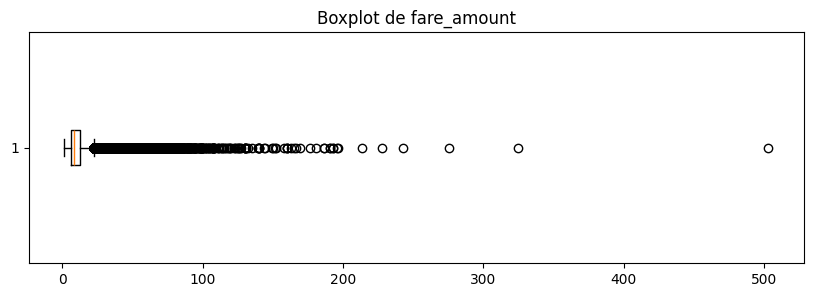

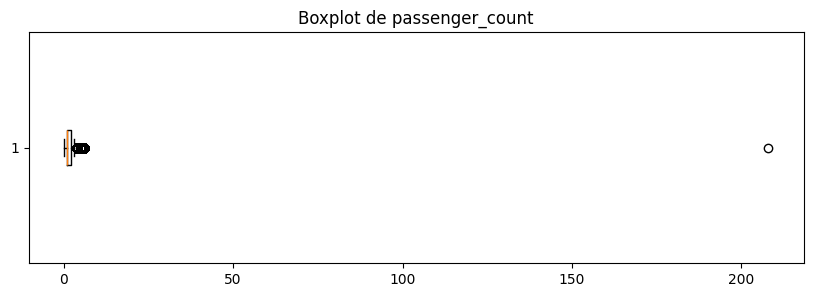

In [21]:
import matplotlib.pyplot as plt

columnas_numericas = [
    'fare_amount',
    'passenger_count'
]

for col in columnas_numericas:
    plt.figure(figsize=(10, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f'Boxplot de {col}')
    plt.show()

# primer vistazo a Boxplot de costo de viaje y de cuenta de pasajeros  
En el primer boxplot, fare_amount, se aprecia que la gran mayoría de los datos tienen valores bajos, mientras que hay pocos viajes de montos más elevados. En futuros pasos del analisis se determinará mejores aproximaciones de la distribución.  
en pasenger_count se puede ver que hay un viaje con más de doscientos pasajeros, se asume que es un error de input, se estudiará esa entry mejor y se determinará que hacer con ella.